In [20]:
import numpy as np
import pandas as pd 
import statistics as sts 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import confusion_matrix,classification_report,precision_score,accuracy_score,f1_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [21]:
from matplotlib import pyplot as plt 
import joblib
import streamlit as st 

In [22]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\tips.csv",encoding_errors='ignore')

In [23]:
df1.sample(10)

,total_bill,tip,sex,smoker,day,time,size
92,5.75,1.00,Female,Yes,Fri,Dinner,2
166,20.76,2.24,Male,No,Sun,Dinner,2
142,41.19,5.00,Male,No,Thur,Lunch,5
225,16.27,2.50,Female,Yes,Fri,Lunch,2
129,22.82,2.18,Male,No,Thur,Lunch,3
28,21.70,4.30,Male,No,Sat,Dinner,2
81,16.66,3.40,Male,No,Thur,Lunch,2
200,18.71,4.00,Male,Yes,Thur,Lunch,3
112,38.07,4.00,Male,No,Sun,Dinner,3
216,28.15,3.00,Male,Yes,Sat,Dinner,5


In [24]:
df2=df1.copy()

In [25]:
df2.drop_duplicates(inplace=True)

In [26]:
df2.isna().sum().to_dict()

{'total_bill': 0,
 'tip': 0,
 'sex': 0,
 'smoker': 0,
 'day': 0,
 'time': 0,
 'size': 0}

In [27]:
df2.isnull().sum().to_dict()

{'total_bill': 0,
 'tip': 0,
 'sex': 0,
 'smoker': 0,
 'day': 0,
 'time': 0,
 'size': 0}

In [28]:
df2.size

1701

In [29]:
df2.ndim

2

In [30]:
df2.shape

(243, 7)

In [31]:
df2.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000


In [32]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  243 non-null    float64
 1   tip         243 non-null    float64
 2   sex         243 non-null    object 
 3   smoker      243 non-null    object 
 4   day         243 non-null    object 
 5   time        243 non-null    object 
 6   size        243 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 15.2+ KB


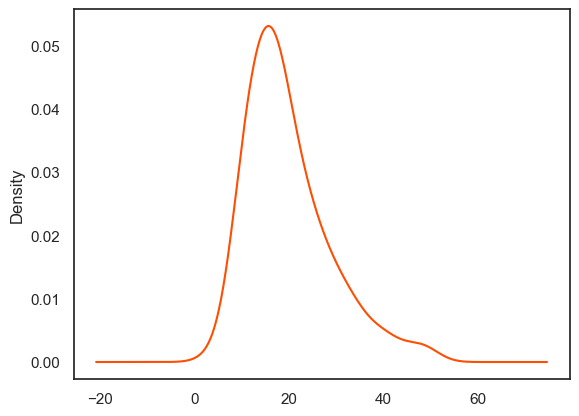

In [43]:
df2['total_bill'].plot(kind='kde')
plt.show()

In [39]:
numerical_columns=df2.select_dtypes(include='number',exclude='object')
print(list(numerical_columns))
catagerical_columns=df2.select_dtypes(include='object',exclude='number')
print(list(catagerical_columns))

['total_bill', 'tip', 'size']
['sex', 'smoker', 'day', 'time']


In [38]:
df2[['sex','smoker','day','lunch_time']]

KeyError: "['lunch_time'] not in index"

In [40]:
df2.drop(columns=['sex','smoker','day','lunch_time'],axis=1,inplace=True)

KeyError: "['lunch_time'] not found in axis"

In [ ]:
label_encoder=LabelEncoder()
df2['day_encoded']=label_encoder.fit_transform(df2['day'])

In [ ]:
df2[['day_encoded','day']].values.tolist()

[[2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [2, 'Sun'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],
 [1, 'Sat'],

In [ ]:
df2[['sex_encoded','sex']]

,sex_encoded,sex
0,0,Female
1,1,Male
2,1,Male
3,1,Male
4,0,Female
...,...,...
239,1,Male
240,0,Female
241,1,Male
242,1,Male


In [ ]:
df2.rename(columns={"time":"lunch_time"},inplace=True)

In [ ]:
x=df2[['sex','smoker','day','lunch_time']]

In [ ]:
df2.columns

Index(['total_bill', 'tip', 'size', 'sex_encoded', 'smoker_encoded',
       'day_encoded'],
      dtype='object')

In [37]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df2['smoker_encoded'])
plt.show()

KeyError: 'smoker_encoded'

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total_bill      243 non-null    float64
 1   tip             243 non-null    float64
 2   size            243 non-null    int64  
 3   sex_encoded     243 non-null    int64  
 4   smoker_encoded  243 non-null    int64  
 5   day_encoded     243 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 13.3 KB


In [ ]:
class AnomoliesDetcetion:
    def __init__(self,data):
        self.data=data 
    def anomolies_function(self,column):
        q1=self.data[column].quantile(0.25)
        q3=self.data[column].quantile(0.75)
        iqr=q3-q1
        left_bound=q1-1.5*iqr 
        right_bound=q3+1.5*iqr 
        return (self.data[column]<left_bound) | (self.data[column]> right_bound)

all_numerics=df2.select_dtypes(include='number',exclude='object')

anomolies_instance=AnomoliesDetcetion(df2)
for each_column in df2.columns:
    anomolies_data=anomolies_instance.anomolies_function(each_column)
    anomolies_count=sum(anomolies_data)
    if anomolies_data.any():
        print(f"{each_column} and {df2[each_column][anomolies_data].values} and count is --> {anomolies_count}")
    else:
        print(f"{each_column}")

total_bill and [48.27 44.3  41.19 48.17 50.81 45.35 40.55 43.11 48.33] and count is --> 9
tip and [ 7.58  6.    6.73  6.7  10.    6.5   9.    6.5 ] and count is --> 8
size and [6 6 5 6 5 6 5 5 5] and count is --> 9
sex_encoded
smoker_encoded
day_encoded


In [ ]:
df3_clean

,total_bill,tip,size,sex_encoded,smoker_encoded,day_encoded
0,16.99,1.01,2,0,0,2
1,10.34,1.66,3,1,0,2
2,21.01,3.50,3,1,0,2
3,23.68,3.31,2,1,0,2
4,24.59,3.61,4,0,0,2
...,...,...,...,...,...,...
239,29.03,5.92,3,1,0,1
240,27.18,2.00,2,0,1,1
241,22.67,2.00,2,1,1,1
242,17.82,1.75,2,1,0,1


In [ ]:
df4_clean=df3_clean.copy()

has_any_anomoliy=pd.Series(False,index=df3_clean.index)

for each_column in df3_clean.columns:
    column_anomolies=anomolies_instance.anomolies_function(each_column)
    has_any_anomoliy=has_any_anomoliy | column_anomolies

df3_clean=df3_clean[~has_any_anomoliy].copy()


In [ ]:
class AnomoliesDetcetion:
    def __init__(self,data):
        self.data=data 
    def anomolies_function(self,column):
        q1=self.data[column].quantile(0.25)
        q3=self.data[column].quantile(0.75)
        iqr=q3-q1
        left_bound=q1-1.5*iqr 
        right_bound=q3+1.5*iqr 
        return (self.data[column]<left_bound) | (self.data[column]> right_bound)

all_numerics=df4_clean.select_dtypes(include='number',exclude='object')

anomolies_instance=AnomoliesDetcetion(df4_clean)
for each_column in df4_clean.columns:
    anomolies_data=anomolies_instance.anomolies_function(each_column)
    anomolies_count=sum(anomolies_data)
    if anomolies_data.any():
        print(f"{each_column} and {df3_clean[each_column][anomolies_data].values} and count is --> {anomolies_count}")
    else:
        print(f"{each_column}")

total_bill and [35.26 34.81 34.83 34.63 34.65 35.83] and count is --> 6
tip
size
sex_encoded
smoker_encoded
day_encoded


In [ ]:
df3_clean

NameError: name 'df3_clean' is not defined

In [ ]:
df4_clean

NameError: name 'df4_clean' is not defined

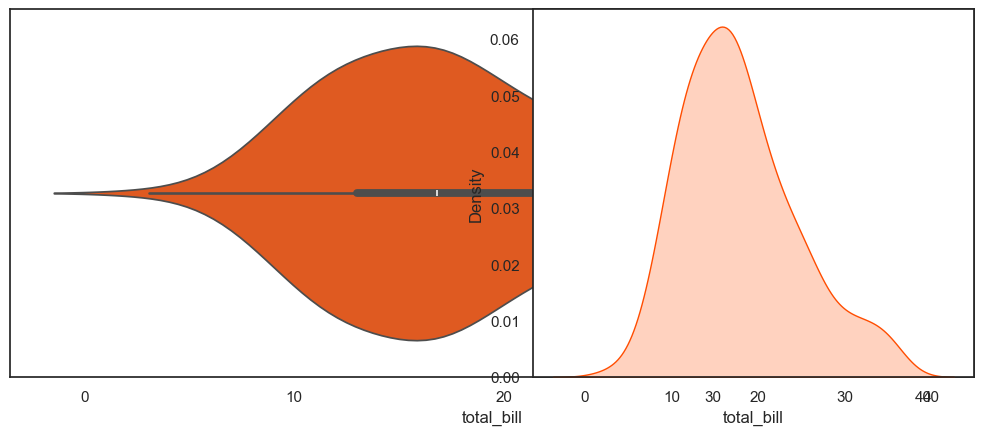

In [ ]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(10,5))




plt.subplot(1,1,1)
sns.violinplot(df4_clean['total_bill'],orient='h')

plt.subplot(1,2,2)
sns.kdeplot(df4_clean['total_bill'],fill=True)


plt.tight_layout()
plt.show()


In [ ]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(10,5))
sns.kdeplot(df4_clean['total_bill'],fill=false)
plt.show()


NameError: name 'df4_clean' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
spearman=df4_clean.corr(method='spearman').round(2)
spearman

,total_bill,tip,size,sex_encoded,smoker_encoded,day_encoded
total_bill,1.00,0.64,0.51,0.12,0.04,-0.04
tip,0.64,1.00,0.37,0.02,0.05,-0.01
size,0.51,0.37,1.00,0.07,-0.18,0.02
sex_encoded,0.12,0.02,0.07,1.00,0.01,-0.06
smoker_encoded,0.04,0.05,-0.18,0.01,1.00,-0.28
day_encoded,-0.04,-0.01,0.02,-0.06,-0.28,1.00


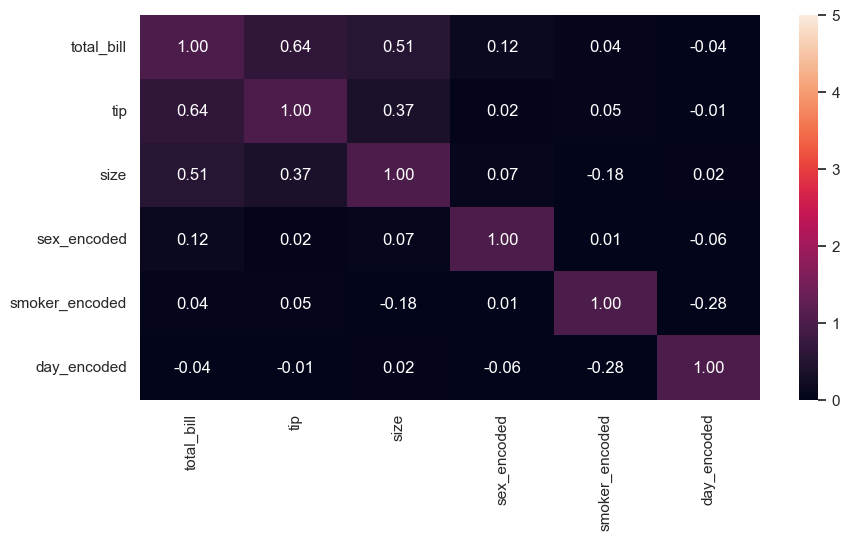

In [ ]:
cl1=['#ff4d01','#ffffff']
plt.figure(figsize=(10,5))
sns.heatmap(spearman,fmt=".2f",annot=True,vmin=0,vmax=5,cbar=True,alpha=1)
plt.show()

In [ ]:
df4_clean.columns

Index(['total_bill', 'tip', 'size', 'sex_encoded', 'smoker_encoded',
       'day_encoded'],
      dtype='object')

In [ ]:
df4_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 0 to 243
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total_bill      217 non-null    float64
 1   tip             217 non-null    float64
 2   size            217 non-null    int64  
 3   sex_encoded     217 non-null    int64  
 4   smoker_encoded  217 non-null    int64  
 5   day_encoded     217 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 11.9 KB


In [ ]:
df4_clean.describe()

,total_bill,tip,size,sex_encoded,smoker_encoded,day_encoded
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,17.845668,2.745300,2.387097,0.631336,0.368664,1.732719
std,6.627285,1.042822,0.731196,0.483558,0.483558,0.934170
min,3.070000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,13.000000,2.000000,2.000000,0.000000,0.000000,1.000000
50%,16.820000,2.560000,2.000000,1.000000,0.000000,2.000000
75%,21.500000,3.480000,3.000000,1.000000,1.000000,3.000000
max,35.830000,5.650000,4.000000,1.000000,1.000000,3.000000


In [ ]:
df4_clean.isna().sum()

total_bill        0
tip               0
size              0
sex_encoded       0
smoker_encoded    0
day_encoded       0
dtype: int64

In [ ]:
df4_clean.drop_duplicates(inplace=True)

In [ ]:
df4_clean.isnull().sum()

total_bill        0
tip               0
size              0
sex_encoded       0
smoker_encoded    0
day_encoded       0
dtype: int64

In [ ]:
x=df4_clean[['total_bill','sex_encoded','smoker_encoded','day_encoded']]
y=df4_clean['tip']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeRegressor


decesion_tree=DecisionTreeRegressor(max_depth=4,min_samples_split=20,min_samples_leaf=6)

In [ ]:
df4_clean.skew()

total_bill        0.674543
tip               0.585517
size              1.258653
sex_encoded      -0.548262
smoker_encoded    0.548262
day_encoded      -0.061393
dtype: float64

In [ ]:
from sklearn.model_selection import cross_val_score


cross_score=cross_val_score(decesion_tree,x,y,cv=10,scoring='r2')
print(cross_score)

cross_mean_error=np.mean(cross_score)
print(cross_mean_error)

[ 0.28964973  0.38273837  0.12545059  0.65365091  0.29175301 -0.702595
  0.27982348 -0.57732401  0.17386608 -0.6235079 ]
0.02935052791258792


In [ ]:
from sklearn.model_selection import GridSearchCV
params_grid={'criterion':['squared_error','absolute_error'],'max_depth':[2,3,4,5,6],'min_samples_split':[2,3,4,5,6,8]}
grid_search=GridSearchCV(estimator=decesion_tree,param_grid=params_grid,n_jobs=-1,scoring='r2',cv=10)
grid_search


,estimator,DecisionTreeR...ples_split=20)
,param_grid,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [ ]:
grid_search.fit(x_train,y_train)


,estimator,DecisionTreeR...ples_split=20)
,param_grid,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [ ]:

from sklearn.metrics import f1_score, mean_absolute_error,r2_score

y_pred=grid_search.predict(x_test)
print(y_pred)


print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

[2.42352941 3.12965517 2.42352941 1.8885     3.12965517 3.12965517
 3.12965517 3.12965517 1.8885     2.42352941 3.12965517 3.12965517
 1.8885     2.42352941 3.12965517 1.8885     3.12965517 3.12965517
 1.8885     1.8885     1.8885     3.12965517 4.1525     2.42352941
 1.8885     3.12965517 3.12965517 1.8885     3.12965517 1.8885
 3.12965517 1.8885     1.8885     3.12965517 1.8885     2.42352941
 3.12965517 1.8885     2.42352941 2.42352941 3.12965517 3.12965517
 1.8885     1.8885    ]
0.5024842451865394
0.5660205375253549


In [ ]:
from sklearn.metrics import root_mean_squared_error


decesion_tree.fit(x_train,y_train)
y1_pred=decesion_tree.predict(x_test)
print(y1_pred)

print(r2_score(y_test,y1_pred))
print(mean_absolute_error(y_test,y1_pred))
print(root_mean_squared_error(y_test,y1_pred))


[2.68823529 3.34764706 2.15882353 1.79142857 3.27761905 3.27761905
 3.68818182 3.27761905 1.59125    2.15882353 3.68818182 2.78868421
 1.59125    2.15882353 2.78868421 1.79142857 3.68818182 2.78868421
 1.59125    1.59125    1.59125    2.78868421 4.1525     2.68823529
 1.59125    3.27761905 3.68818182 2.5        3.27761905 1.59125
 3.27761905 1.59125    1.79142857 3.34764706 1.79142857 2.15882353
 2.78868421 1.79142857 2.15882353 2.68823529 3.34764706 3.34764706
 1.79142857 1.59125   ]
0.4745739726828734
0.5590036295618727
0.7430780586660689


In [ ]:
import joblib

joblib.dump(decesion_tree,"tipspredication.joblib")

['tipspredication.joblib']

array(['total_bill', 'sex_encoded', 'smoker_encoded', 'day_encoded'],
      dtype=object)

In [ ]:
df4_clean.info()


NameError: name 'df4_clean' is not defined